<a href="https://colab.research.google.com/github/caballeroarturo/CAN_IntroProg/blob/main/Matem%C3%A1ticas/Trigonometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gráfica de funciones trigonométricas

## Código

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import inspect  # <--- Nueva librería para "leer" la fórmula que escribiste

def graficar_funcion(funcion, etiqueta="f(x)", inicio=-2*np.pi, fin=2*np.pi, puntos=1000, mostrar_comparacion=True):
    """
    Grafica cualquier función y, OPCIONALMENTE, superpone la función sen(x) o cos(x) base.

    Parámetros:
    - funcion: función de Python (ej: lambda x: np.sin(2*x))
    - etiqueta: texto para la leyenda
    - inicio, fin: rango del eje X (en radianes)
    - puntos: cantidad de puntos para suavizar la curva
    - mostrar_comparacion: True (por defecto) para mostrar sen(x) o cos(x) de fondo.
    """
    # 1. Generar los datos de la función principal
    x = np.linspace(inicio, fin, puntos)
    y = funcion(x)

    # 2. Crear la figura
    plt.figure(figsize=(12, 5))

    # --- DETECCIÓN AUTOMÁTICA DE LA FUNCIÓN BASE (seno o coseno) ---
    funcion_base = None
    etiqueta_base = ""

    if mostrar_comparacion:
        try:
            # Obtenemos el código fuente de la lambda (ej: "lambda x: np.sin(2*x)")
            fuente = inspect.getsource(funcion).strip()

            # Buscamos si dentro de la fórmula aparece 'np.sin' o 'np.cos'
            if 'np.sin' in fuente or 'sin(' in fuente:
                funcion_base = np.sin
                etiqueta_base = 'sen(x)'
            elif 'np.cos' in fuente or 'cos(' in fuente:
                funcion_base = np.cos
                etiqueta_base = 'cos(x)'

        except (TypeError, OSError):
            # Si no se puede leer la fuente (ej: función precompilada), simplemente no la mostramos
            pass

    # Si se detectó una función base, la dibujamos en segundo plano (punteada y gris)
    if funcion_base is not None:
        y_base = funcion_base(x)
        plt.plot(x, y_base,
                 label=f'{etiqueta_base} (base)',
                 color='gray',
                 linestyle='--',
                 linewidth=1.5,
                 alpha=0.6)  # alpha = transparencia

    # 3. Dibujar la función PRINCIPAL (encima de la base)
    plt.plot(x, y, label=etiqueta, color='#1f77b4', linewidth=2.5)

    # 4. Ejes centrales
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)

    # 5. Generar marcas en el eje X en múltiplos de π/2 (de forma automática)
    paso = np.pi / 2
    primer_multiplo = np.ceil(inicio / paso) * paso
    ultimo_multiplo = np.floor(fin / paso) * paso
    marcas_x = np.arange(primer_multiplo, ultimo_multiplo + paso, paso)

    etiquetas_x = []
    for val in marcas_x:
        coef = val / np.pi
        if coef == 0:
            etiquetas_x.append('0')
        elif coef == 1:
            etiquetas_x.append('π')
        elif coef == -1:
            etiquetas_x.append('-π')
        elif coef == 0.5:
            etiquetas_x.append('π/2')
        elif coef == -0.5:
            etiquetas_x.append('-π/2')
        elif coef == 1.5:
            etiquetas_x.append('3π/2')
        elif coef == -1.5:
            etiquetas_x.append('-3π/2')
        elif coef == 2:
            etiquetas_x.append('2π')
        elif coef == -2:
            etiquetas_x.append('-2π')
        else:
            if coef > 0:
                etiquetas_x.append(f'{int(coef)}π/2' if coef != int(coef) else f'{int(coef)}π')
            else:
                etiquetas_x.append(f'{int(coef)}π/2' if coef != int(coef) else f'{int(coef)}π')

    plt.xticks(marcas_x, etiquetas_x)

    # 6. Ajustar el límite del eje Y para que se vea bien la comparación (si es seno puro, de -1.5 a 1.5)
    # Pero si la función tiene amplitudes muy grandes, mejor dejarlo automático.
    # Si quieres fijarlo para senos, descomenta la línea de abajo:
    # plt.ylim(-1.5, 1.5)

    # 7. Etiquetas, título y cuadrícula
    plt.title(f'Gráfica de {etiqueta} comparada con su base', fontsize=16)
    plt.xlabel('x (radianes)', fontsize=12)
    plt.ylabel(etiqueta, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')

    plt.show()

## Función seno

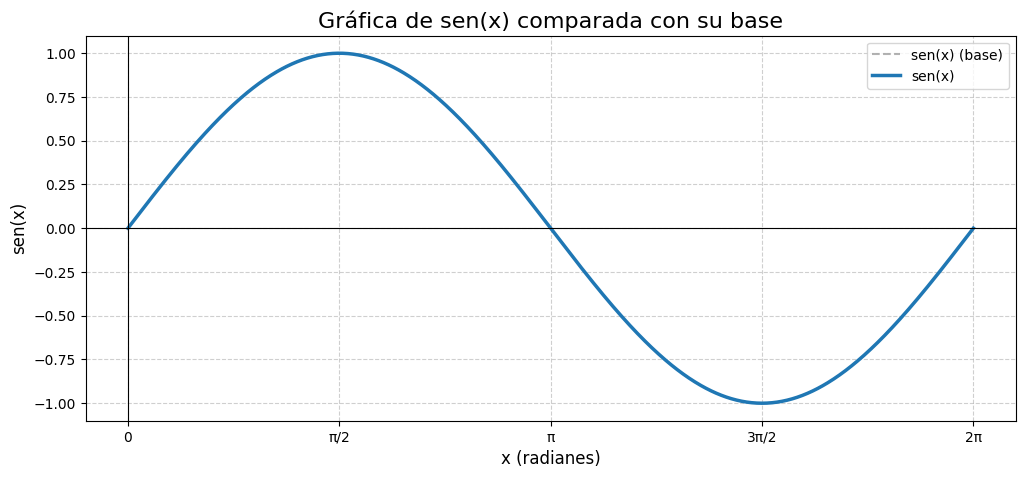

In [36]:
graficar_funcion(lambda x: np.sin(x), "sen(x)", inicio=0, fin=2*np.pi)

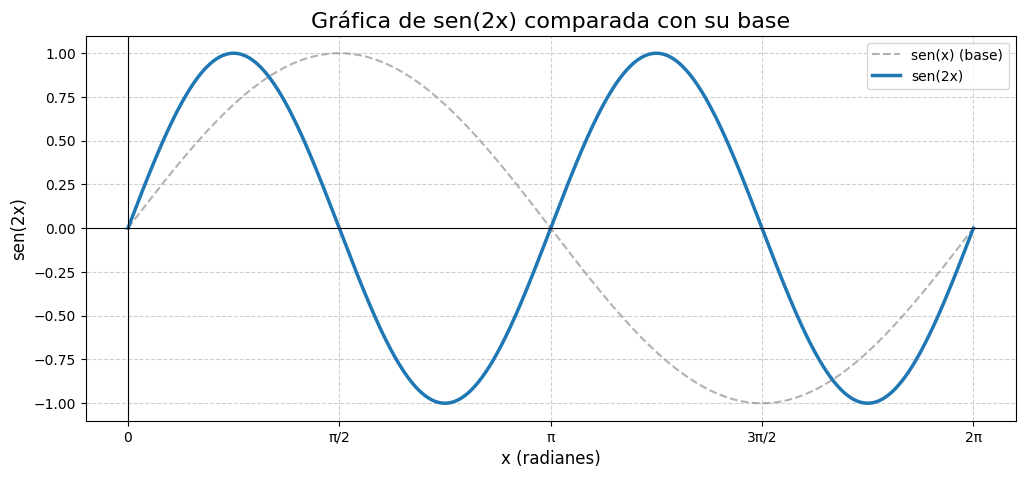

In [33]:
graficar_funcion(lambda x: np.sin(2*x), "sen(2x)", inicio=0, fin=2*np.pi)

## Función coseno

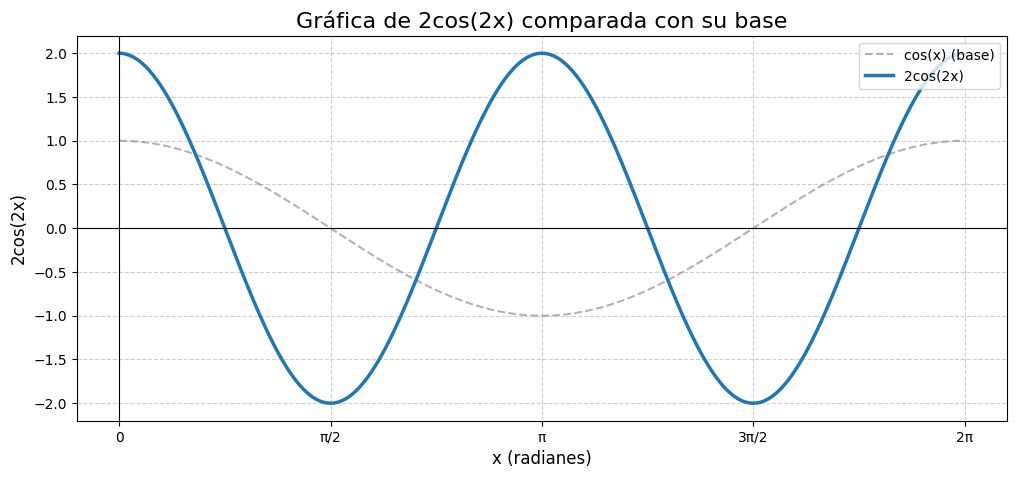

In [38]:
graficar_funcion(lambda x: 2*np.cos(2*x), "2cos(2x)", inicio=0, fin=2*np.pi)